This program can be used to check if all chosen GRCD stations are a good fit for regionalization (matching and non-overlapping basins).  

In [2]:
# Python-Module für System- und Dateimanagement
import os  # Betriebssystem-Interaktionen
import sys  # Systembezogene Funktionen
from sys import platform  # Erkennen des Betriebssystems
import shutil  # Datei- und Verzeichnisoperationen
import glob  # Suchen von Dateien mit Muster
import stat  # Datei- und Verzeichnisrechte
import time  # Zeitmessung und -steuerung
import datetime  # Arbeiten mit Datum und Uhrzeit
import multiprocessing  # Parallele Verarbeitung
import subprocess  # Ausführen externer Prozesse
from subprocess import Popen, PIPE  # Alternative Möglichkeit für Subprozess-Kommunikation
import pickle  # Speichern und Laden von Python-Objekten (Serialisierung)
import ast  # Abstrakte Syntaxbäume (z. B. Umwandlung von Strings in Python-Objekte)
import configparser  # Einlesen und Schreiben von Konfigurationsdateien
from configparser import ConfigParser  # Alternative Schreibweise

# Numerische Berechnungen & Zufallszahlen
import array  # Arbeit mit Arrays
import random  # Zufallszahlengenerierung
import numpy as np  # Wissenschaftliches Rechnen mit Arrays
from collections import defaultdict, Counter

# Datenverarbeitung & Analyse 
import csv  # Lesen und Schreiben von CSV-Dateien
import xarray as xr  # Arbeiten mit multidimensionalen Arrays (z. B. für NetCDF-Daten)
import cftime  # Arbeiten mit Klimazeitdaten (z. B. NetCDF-Dateien)
import pandas as pd  # Datenanalyse und Tabellenverarbeitung

# Visualisierung
import matplotlib.pyplot as plt  # Erstellen von Diagrammen
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches  

# Geografische Daten & Karten
import cartopy.crs as ccrs  # Koordinatenreferenzsysteme
import cartopy.feature as cfeature  # Geografische Features (z. B. Küstenlinien, Ländergrenzen)
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER  # Formatieren von Kartenrastern
import geopandas as gpd  # Verarbeiten von Geodaten, insbesondere Shapefiles
from shapely.geometry import Point  # Arbeiten mit geometrischen Objekten
from osgeo import gdal  # Geodatenformate lesen/schreiben (z. B. Rasterdaten)

# ANSI-Farbcodes definieren
RED = "\033[91m"
GREEN = "\033[92m"
YELLOW = "\033[93m"

# Paths

In [11]:
root_path_STEP0 = '../Step0_preparationGRDCFiles'
root_path_STEP2 = '../Step2_individualCalibrationFiles'
# GRDC stations
GRDCFilename = 'GRDC_40calibrationStations_FINAL'

#### Output-Path für die Abbildungen

In [9]:
output_path_graphs = 'Figures_Step3A_regionalisationFiles' 

# 1. Read in GRDC data und HydroBasins data

In [12]:
# Read in GRDC-data-file
xr_grdc = xr.open_dataset(root_path_STEP0 + '/GRDC_data/GRDC_calibrationStations/' + GRDCFilename + '_LatLonFit.nc')
list_of_station_IDs = xr_grdc['id'].values

# GRDC coordinates
lon_station = {}
lat_station = {}
for ID in list_of_station_IDs: 
    lon_station [ID] = xr_grdc['geo_x'].sel(id = ID).values
    lat_station [ID] = xr_grdc['geo_y'].sel(id = ID).values

lon_station_fit = {}
lat_station_fit = {}
for ID in list_of_station_IDs: 
    lon_station_fit [ID] = xr_grdc['gauged_lon'].sel(id = ID).values
    lat_station_fit [ID] = xr_grdc['gauged_lat'].sel(id = ID).values

# Read HybasID
HybasID_DICT = {}
for ID in list_of_station_IDs: 
      HybasID_DICT [ID] = xr_grdc['OBJECTID'].sel(id = ID).values.item()

HybasID_list =  [HybasID_DICT [ID] for ID in list_of_station_IDs]  

In [6]:
# Hydrological Basins from HydroBasins
xr_hybas = xr.open_dataset(root_path_STEP0 + '/HydroBasins_data/hybas_eu_lev05_v1c.nc')

# 2. Final choice of station IDs for regional calibration
Stations used for regionalization of calibration need to fulfill the following criteria:
1) each hydrological basin (from HydroBasins) should only contain one GRDC station
2) each GRDC station needs to have a matching UpstreamArea in C-CWatM (generated in 'cellArea_totalend.nc' by C-CWatM)
3) minimize overlap between C-CWatM upstream river basins for different GRDC stations
4) ideally, C-CWatM upstream areas should be confined within one HydroBasin "hybas_level5" basin

## Original choice of stations

In [7]:
print('Original number of stations in GRDC-file: ' +  str(len(list_of_station_IDs)))
print(list_of_station_IDs)

Ursprüngliche Anzahl an IDs im GRDC-file: 40 Stück
[6113050 6116200 6122260 6123400 6125100 6136145 6140400 6142150 6172050
 6212740 6226800 6227510 6232911 6233410 6233510 6243050 6335240 6337200
 6342501 6357500 6373304 6421100 6444600 6457870 6458450 6545050 6547110
 6574150 6606655 6646800 6729450 6730501 6731555 6742700 6744201 6781800
 6854250 6854700 6935051 6939050]


## 1) Only one GRDC station per hydro basin 

In [8]:
HybasID_list =  [HybasID_DICT [ID] for ID in list_of_station_IDs]  

# Dictionary with station IDs and corresponding HybasIDs 
HybasID_SORT = defaultdict(list)
for hybasID, stationID in zip(HybasID_list, list_of_station_IDs):
    HybasID_SORT[hybasID].append(stationID)
    
# Filter dictionary to keep only HybasIDs with more that 1 occurrrence
hybasID_count = Counter(HybasID_list)
multiple_HybasIDs = {hybasID: stationID for hybasID, stationID in HybasID_SORT.items() if hybasID_count[hybasID] > 1}

# Print
if len(multiple_HybasIDs) > 0:  
    print(f'Stations that belong to the same HybasID:')
    for hybasID, IDs in multiple_HybasIDs.items():
        print(f"Stationen: {IDs}, HybasID: {hybasID}")
else:
    print(f"No stations belong to the same HydroBasin!")

ENTWARNUNG: Verschiedene Stationen gehören niemals zur gleichen HydbasID.


## 2) C-CWatM upstream area exists for each GRDC station

In [9]:
missing_list_of_station_IDs = []
for ID in list_of_station_IDs: 
    try: 
        upstream_area = xr.open_dataset(root_path_STEP2 + '/outputFiles/' + str(ID) + '/41_best/' + 'cellArea_totalend.nc')    
    except Exception:
        missing_list_of_station_IDs.append(ID)
        pass

# Ausgabe
if len(np.array(missing_list_of_station_IDs)) > 0:  
    print(f"{RED}WARNING: File 'cellArea_totalend.nc' not found for ", len(np.array(missing_list_of_station_IDs)))
    print(np.array(missing_list_of_station_IDs))
else:
    print(f"{RED}OK: File 'cellArea_totalend.nc' found for all stations.") 

ENTWARNUNG: File 'cellArea_totalend.nc' wurde für alle Stationen gefunden.


## 3) Minimize overlap between C-CWatM upstream river basins for different GRDC stations

In [3]:
print(f"{RED}WARNING: Check overlap in figure 'stations_UpstreamAreas'")

## 4) C-CWatM upstream areas confined within one HydroBasin "hybas_level5" basin

In [4]:
print(f"{RED}WARNING: Check figure 'stations_HybasBasins_UpstreamAreas'")

## Final list of GRDC stations

In [13]:
################     THAT'S WHAT IS MOST IMPORTANT, TO COPY FOR STEP 3B #########################
# Stationens to be removed from original GRDC-File
list_of_removed_stations_IDs = np.array([ ])
################     THAT'S WHAT IS MOST IMPORTANT, TO COPY FOR STEP 3B    #########################

In [14]:
# Finale Anzahl und Auswahl an Station IDs für den Calibration Prozess
optimized_list_of_station_IDs = np.setdiff1d(list_of_station_IDs, list_of_removed_stations_IDs)
print('Remaining station IDs for regionalisation: ' + str(len(optimized_list_of_station_IDs)))
print(optimized_list_of_station_IDs) 

Remaining station IDs for regionalisation: 40
[6113050 6116200 6122260 6123400 6125100 6136145 6140400 6142150 6172050
 6212740 6226800 6227510 6232911 6233410 6233510 6243050 6335240 6337200
 6342501 6357500 6373304 6421100 6444600 6457870 6458450 6545050 6547110
 6574150 6606655 6646800 6729450 6730501 6731555 6742700 6744201 6781800
 6854250 6854700 6935051 6939050]


In [5]:
# --- Checked by hand ---
# Basins that are not ideal:
# UpstreamArea mosty outside of corresponding HydroBasin
class3 = np.array([ 6140400, 6457870, 6935051 ])

# Prüfen, ob class3 nicht leer ist
if class3.size > 0:  
    print(" ")
    print(f"{RED}WARNING: There are ", len(class3), f" station IDs, with non-ideal overlaps.")

# 3. Plotting of basins

#### Stations and their HybasBasins

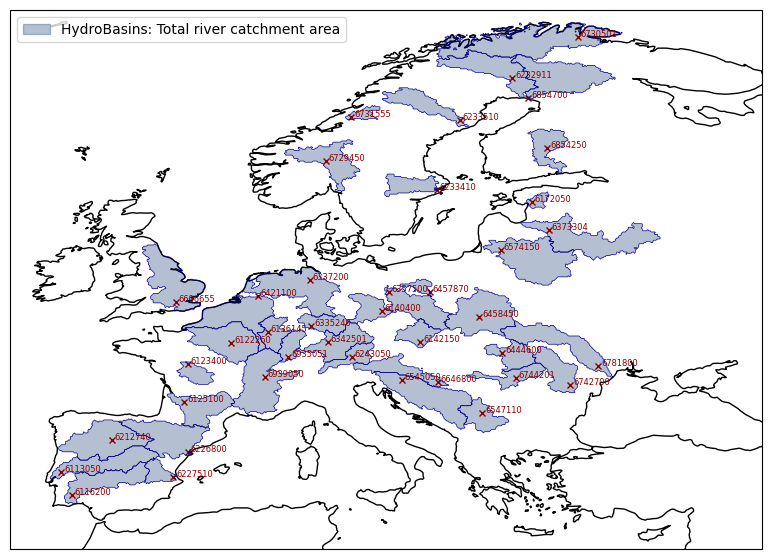

In [15]:
# Create a map figure with matplotlib and cartopy
A_lon, A_lat, B_lon, B_lat = -12 , 34 , 41 , 72
choosen_projection = ccrs.PlateCarree()  
fig,ax = plt.subplots(figsize=(18, 7),subplot_kw={'projection': choosen_projection})
ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs = choosen_projection)
ax.coastlines(linewidth=1, linestyle='-')

# Color map for the areas
cmapBlue = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=1)  # Define the range for the color map

for ID in optimized_list_of_station_IDs:  
    ax.plot(xr_grdc.gauged_lon.sel(id=ID), xr_grdc.gauged_lat.sel(id=ID),  'x' , color='darkred' , markersize=5, transform = choosen_projection)
    ax.text(xr_grdc.gauged_lon.sel(id=ID) + 0.2 , xr_grdc.gauged_lat.sel(id=ID) , str(ID),  color='darkred' , fontsize= 6 , transform = choosen_projection)
    Hybas_ID = float(xr_grdc.sel(id=ID).OBJECTID.values)   
    filtered_xr_hybas = xr_hybas.where(xr_hybas.sub_basin_mask == Hybas_ID, drop=True)
    map_filtered_hybas = filtered_xr_hybas.sub_basin_mask
    map_filtered_hybas.plot(x='lon', y='lat', ax=ax, add_colorbar=False, alpha=0.3, cmap=cmapBlue, norm=norm)
    mask = xr.where(xr_hybas.sub_basin_mask == Hybas_ID, 1, 0)
    lon2d, lat2d = np.meshgrid(mask.lon, mask.lat, indexing='ij')
    ax.contour(lon2d, lat2d, mask, levels=[0.5], colors='darkblue', linewidths=0.5, transform=choosen_projection)

# Legend
blue_patch = mpatches.Patch(color=cmapBlue (0.99),  alpha=0.3, label='HydroBasins: Total river catchment area')
ax.legend(handles=[blue_patch], loc='upper left')  
plt.savefig(output_path_graphs + '/' +  'figSTEP3A_Nr1_stations_HydroBasins'  + '.jpg',  dpi=300, bbox_inches='tight')
plt.show()


#### Stations and their UpstreamAreas

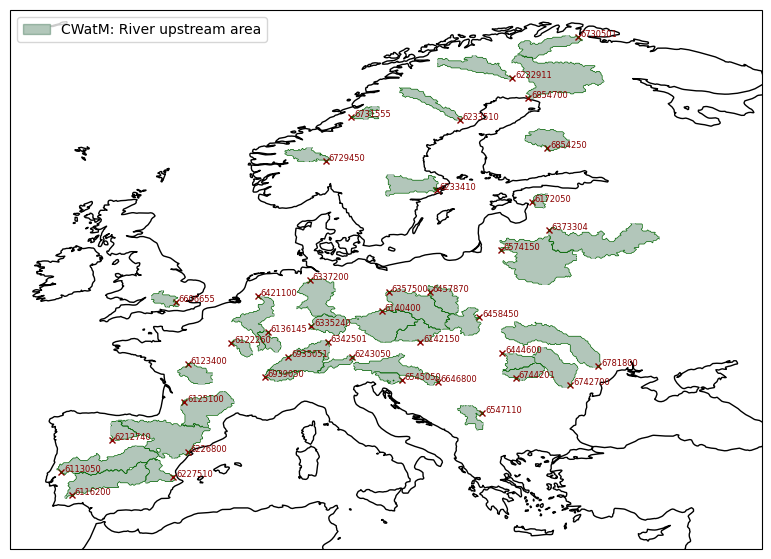

In [16]:
# Create a map figure with matplotlib and cartopy
A_lon, A_lat, B_lon, B_lat = -12 , 34 , 41 , 72
choosen_projection = ccrs.PlateCarree()  
fig,ax = plt.subplots(figsize=(18, 7),subplot_kw={'projection': choosen_projection})
ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs = choosen_projection)
ax.coastlines(linewidth=1, linestyle='-')

# Color map for the areas
cmapBlue = plt.cm.Blues
cmapGreen = plt.cm.Greens
norm = mcolors.Normalize(vmin=0, vmax=1)  

for ID in optimized_list_of_station_IDs : 
    ax.plot(xr_grdc.gauged_lon.sel(id=ID), xr_grdc.gauged_lat.sel(id=ID),  'x' , color='darkred' , markersize=5, transform = choosen_projection)
    ax.text(xr_grdc.gauged_lon.sel(id=ID) + 0.2 , xr_grdc.gauged_lat.sel(id=ID) , str(ID),  color='darkred' , fontsize= 6 , transform = choosen_projection)
    upstream_area =  xr.open_dataset(root_path_STEP2 + '/outputFiles/' + str(ID) + '/41_best/' + 'cellArea_totalend.nc')   
    upstream_area.cellArea_totalend.plot(ax=ax, add_colorbar=False, alpha=0.3, cmap=cmapGreen, norm=norm)
    mask_upstream = xr.where(upstream_area.cellArea_totalend > 0, 1, 0).fillna(0)
    lon2d, lat2d = np.meshgrid(mask_upstream.lon, mask_upstream.lat)
    ax.contour(lon2d, lat2d, mask_upstream, levels=[0.5], colors='darkgreen', linewidths=0.5, transform=choosen_projection)   

# Legend
green_patch = mpatches.Patch(color = cmapGreen(0.99),  alpha=0.3, label='CWatM: River upstream area')
ax.legend(handles=[green_patch], loc='upper left')  
plt.savefig(output_path_graphs + '/' +  'figSTEP3A_Nr2_stations_UpstreamAreas'  + '.jpg',  dpi=300, bbox_inches='tight')
plt.show()

#### Stations, their HydroBasins and their UpstreamAreas

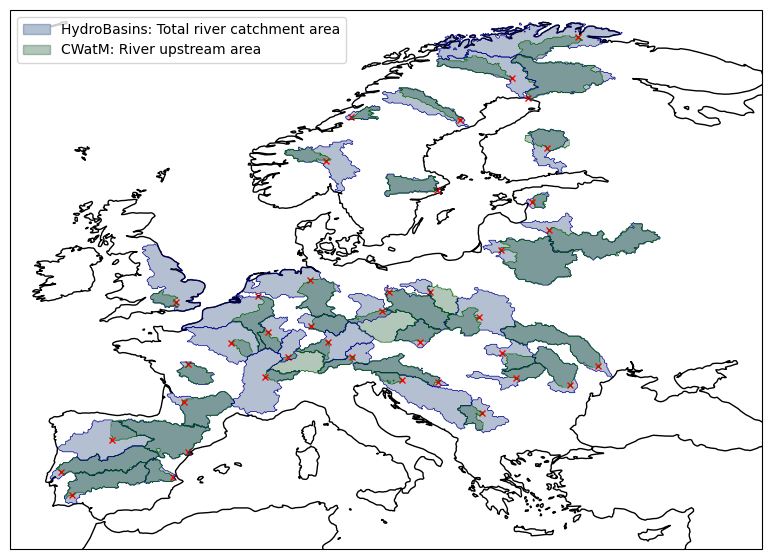

In [17]:
# Create a map figure with matplotlib and cartopy
A_lon, A_lat, B_lon, B_lat = -12 , 34 , 41 , 72
choosen_projection = ccrs.PlateCarree()  
fig,ax = plt.subplots(figsize=(18, 7),subplot_kw={'projection': choosen_projection})
ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs = choosen_projection)
ax.coastlines(linewidth=1, linestyle='-')

# Color map for the areas
cmapBlue = plt.cm.Blues
cmapGreen = plt.cm.Greens
norm = mcolors.Normalize(vmin=0, vmax=1)  

for ID in optimized_list_of_station_IDs:
    ax.plot(xr_grdc.gauged_lon.sel(id=ID), xr_grdc.gauged_lat.sel(id=ID),  'x' , color='r' , markersize=5, transform = choosen_projection)
    Hybas_ID = float(xr_grdc.sel(id=ID).OBJECTID.values)   
    filtered_xr_hybas = xr_hybas.where(xr_hybas.sub_basin_mask == Hybas_ID, drop=True)
    map_filtered_hybas = filtered_xr_hybas.sub_basin_mask
    map_filtered_hybas.plot(x='lon', y='lat', ax=ax, add_colorbar=False, alpha=0.3, cmap=cmapBlue, norm=norm)
    mask = xr.where(xr_hybas.sub_basin_mask == Hybas_ID, 1, 0)
    lon2d, lat2d = np.meshgrid(mask.lon, mask.lat, indexing='ij')
    ax.contour(lon2d, lat2d, mask, levels=[0.5], colors='darkblue', linewidths=0.5, transform=choosen_projection)
    upstream_area = xr.open_dataset(root_path_STEP2 + '/outputFiles/' + str(ID) + '/41_best/' + 'cellArea_totalend.nc') 
    upstream_area.cellArea_totalend.plot(ax=ax, add_colorbar=False, alpha=0.3, cmap=cmapGreen, norm=norm)
    mask_upstream = xr.where(upstream_area.cellArea_totalend > 0, 1, 0).fillna(0)
    lon2d, lat2d = np.meshgrid(mask_upstream.lon, mask_upstream.lat)
    ax.contour(lon2d, lat2d, mask_upstream, levels=[0.5], colors='darkgreen', linewidths=0.5, transform=choosen_projection)   

# Legend
blue_patch = mpatches.Patch(color=cmapBlue (0.99), alpha=0.3, label='HydroBasins: Total river catchment area')
green_patch = mpatches.Patch(color=cmapGreen (0.99), alpha= 0.3, label='CWatM: River upstream area')
ax.legend(handles=[blue_patch, green_patch], loc='upper left')  
plt.savefig(output_path_graphs + '/' +  'figSTEP3A_Nr3_stations_HybasBasins_UpstreamAreas'  + '.jpg',  dpi=300, bbox_inches='tight')
plt.show()

#### Stations, their HydroBasins and their UpstreamAreas [single]

In [18]:

for ID in optimized_list_of_station_IDs:
    fig, ax = plt.subplots(figsize= (7.5, 4.5), subplot_kw={'projection': choosen_projection})
    ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs=choosen_projection)
    ax.coastlines(linewidth=1)

    # HydroBasins plot
    Hybas_ID = float(xr_grdc.sel(id=ID).OBJECTID.values)
    filtered_xr_hybas = xr_hybas.where(xr_hybas.sub_basin_mask == Hybas_ID, drop=True)
    map_filtered_hybas = filtered_xr_hybas.sub_basin_mask
    map_filtered_hybas.plot(x='lon', y='lat', ax=ax, add_colorbar=False, alpha=0.3, cmap=cmapBlue, norm=norm)
    mask = xr.where(xr_hybas.sub_basin_mask == Hybas_ID, 1, 0)
    lon2d, lat2d = np.meshgrid(mask.lon, mask.lat, indexing='ij')
    ax.contour(lon2d, lat2d, mask, levels=[0.5], colors='darkblue', linewidths=0.5, transform=choosen_projection)

    # GRDC station
    ax.plot(xr_grdc.gauged_lon.sel(id=ID), xr_grdc.gauged_lat.sel(id=ID), 'x', color='r', markersize=5, transform=choosen_projection)
   
    # CWatM upstream area
    try:
        upstream_area = xr.open_dataset(root_path_STEP2 + '/outputFiles/' + str(ID) + '/41_best/' + 'cellArea_totalend.nc') 
        upstream_area.cellArea_totalend.plot(ax=ax, add_colorbar=False, alpha=0.3, cmap=cmapGreen, norm=norm)
        mask_upstream = xr.where(upstream_area.cellArea_totalend > 0, 1, 0).fillna(0)
        lon2d, lat2d = np.meshgrid(mask_upstream.lon, mask_upstream.lat)
        ax.contour(lon2d, lat2d, mask_upstream, levels=[0.5], colors='darkgreen', linewidths=0.5, transform=choosen_projection)
    except Exception:
        pass

    # Legende
    blue_patch = mpatches.Patch(color=cmapBlue(0.99), alpha=0.3, label=f'HydroBasins: Total river catchment area for {ID}')
    green_patch = mpatches.Patch(color=cmapGreen(0.99), alpha=0.3, label=f'CWatM: River upstream area for {ID}')
    ax.legend(handles=[blue_patch, green_patch], loc='upper left', fontsize= 6)

    plt.close(fig) 

#### Stations, their HydroBasins and their UpstreamAreas, where it does not fit that well

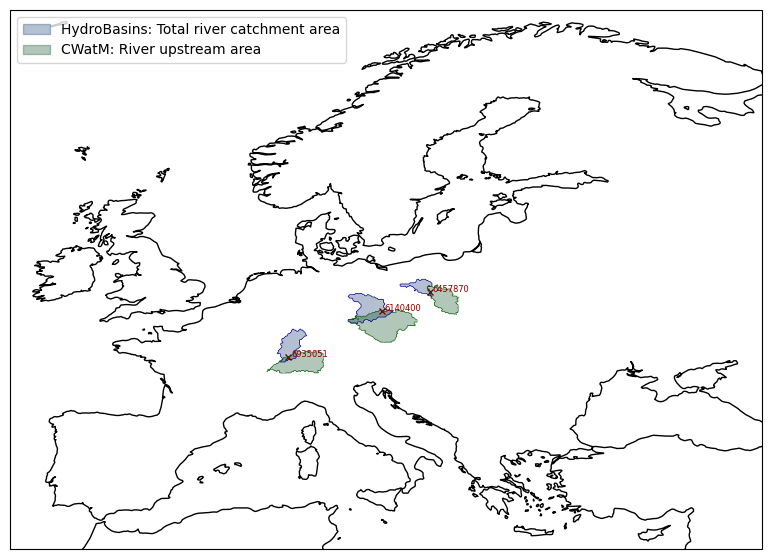

In [19]:
# Create a map figure with matplotlib and cartopy
A_lon, A_lat, B_lon, B_lat = -12 , 34 , 41 , 72
choosen_projection = ccrs.PlateCarree()  
fig,ax = plt.subplots(figsize=(18, 7),subplot_kw={'projection': choosen_projection})
ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs = choosen_projection)
ax.coastlines(linewidth=1, linestyle='-')

# Color map for the areas
cmapBlue = plt.cm.Blues
cmapGreen = plt.cm.Greens
norm = mcolors.Normalize(vmin=0, vmax=1)  

for ID in class3:
    ax.plot(xr_grdc.gauged_lon.sel(id=ID), xr_grdc.gauged_lat.sel(id=ID),  'x' , color='darkred' , markersize=5, transform = choosen_projection)
    ax.text(xr_grdc.gauged_lon.sel(id=ID) + 0.2 , xr_grdc.gauged_lat.sel(id=ID) , str(ID),  color='darkred' , fontsize= 6 , transform = choosen_projection)
    Hybas_ID = float(xr_grdc.sel(id=ID).OBJECTID.values)   
    filtered_xr_hybas = xr_hybas.where(xr_hybas.sub_basin_mask == Hybas_ID, drop=True)
    map_filtered_hybas = filtered_xr_hybas.sub_basin_mask
    map_filtered_hybas.plot(x='lon', y='lat', ax=ax, add_colorbar=False, alpha=0.3, cmap=cmapBlue, norm=norm)
    mask = xr.where(xr_hybas.sub_basin_mask == Hybas_ID, 1, 0)
    lon2d, lat2d = np.meshgrid(mask.lon, mask.lat, indexing='ij')
    ax.contour(lon2d, lat2d, mask, levels=[0.5], colors='darkblue', linewidths=0.5, transform=choosen_projection)
    upstream_area = xr.open_dataset(root_path_STEP2 + '/outputFiles/' + str(ID) + '/41_best/' + 'cellArea_totalend.nc') 
    upstream_area.cellArea_totalend.plot(ax=ax, add_colorbar=False, alpha=0.3, cmap=cmapGreen, norm=norm)
    mask_upstream = xr.where(upstream_area.cellArea_totalend > 0, 1, 0).fillna(0)
    lon2d, lat2d = np.meshgrid(mask_upstream.lon, mask_upstream.lat)
    ax.contour(lon2d, lat2d, mask_upstream, levels=[0.5], colors='darkgreen', linewidths=0.5, transform=choosen_projection)   

# Legend
blue_patch = mpatches.Patch(color=cmapBlue (0.99), alpha=0.3, label='HydroBasins: Total river catchment area')
green_patch = mpatches.Patch(color=cmapGreen (0.99), alpha= 0.3, label='CWatM: River upstream area')
ax.legend(handles=[blue_patch, green_patch], loc='upper left')  
plt.savefig(output_path_graphs + '/' +  'figSTEP3A_Nr4_stations_HybasBasins_UpstreamAreas_badFIT'  + '.jpg',  dpi=300, bbox_inches='tight')
plt.show() 